# Deskriptiv analyse

Dataen er hentet fra filen '2020 Vannforsyningssystem data.xlsx'. 
Metodikken for analysene følger punktene nedenfor:

1. Dataundersøkelse.
2. Rensing og preparering av data
    - Håndetering av manglende data. 
    - Data transformasjon for videre analyser.
3. Visualiserring.
4. Statistikk.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
fil = pd.read_excel('2020 Vannforsyningssystem data.xlsx')

<ipython-input-2-29845fe9f89c>:1: FutureWarning: Your version of xlrd is 1.2.0. In xlrd >= 2.0, only the xls format is supported. As a result, the openpyxl engine will be used if it is installed and the engine argument is not specified. Install openpyxl instead.
  fil = pd.read_excel('2020 Vannforsyningssystem data.xlsx')


### Dataundersøkelse

In [3]:
print(f'Antall obervasjoner i Vannforsynningssytem-filen inkludert korrupt/manglende data: {len(fil)} ')
print()
print(fil.info())

Antall obervasjoner i Vannforsynningssytem-filen inkludert korrupt/manglende data: 5664 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5664 entries, 0 to 5663
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   aktiv                 5664 non-null   object 
 1   mtid_vf               5664 non-null   object 
 2   kommune               3231 non-null   object 
 3   mtregion              5664 non-null   object 
 4   periode               3820 non-null   float64
 5   vannprod              3813 non-null   float64
 6   beredskap             4868 non-null   object 
 7   beredsk_oppd          3812 non-null   object 
 8   beredsk_ovelse        3812 non-null   object 
 9   forbr_fast_bosetting  1940 non-null   object 
 10  forbr_fritidsboliger  1911 non-null   object 
 11  forbr_industri        1884 non-null   float64
 12  forbr_tjytende        1874 non-null   float64
 13  forbr_primnaering     1896 non-nu

Ser på de første 5 observasjoner

In [4]:
fil.head(5)

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
0,ja,Z0704301334220581190KVPHB,Bærum,Region Stor-Oslo,2020.0,11000.0,ja,ja,ja,58,0,0.0,0.0,0,10,32.0
1,ja,Z0704301334229761190PVHZK,Ålesund,Region Midt,2020.0,42000.0,ja,nei,nei,35,15,5.0,0.0,35,0,10.0
2,nei,Z0704301334311811190DXMOL,Gjerstad,Region Sør og Vest,2010.0,9000.0,nei,nei,nei,80,1,0.0,0.0,19,0,0.0
3,nei,Z0704301334335091189ACHFQ,Giske,Region Midt,2009.0,0.0,ja,nei,nei,80,NaN,NaN,NaN,NaN,10,10.0
4,ja,Z0704301334355061189GZVWT,Ålesund,Region Midt,2020.0,0.0,ja,ja,ja,6,3,74.0,1.0,5,2,9.0


Ser på de siste 5 observasjoner.

In [5]:
fil.tail(5)

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
5659,nei,Z1606140937365193132SVKBW,NaN,Region Midt,NaN,NaN,ja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5660,nei,Z0704301338362391189XYFKP,NaN,Region Øst,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5661,nei,Z0704301338315951190KSIUH,NaN,Region Nord,NaN,NaN,nei,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5662,nei,Z1602271032035093252YVWML,NaN,Region Øst,NaN,NaN,ja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5663,ja,Z1901221421385613252KRTKK,NaN,Region Stor-Oslo,NaN,NaN,ja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


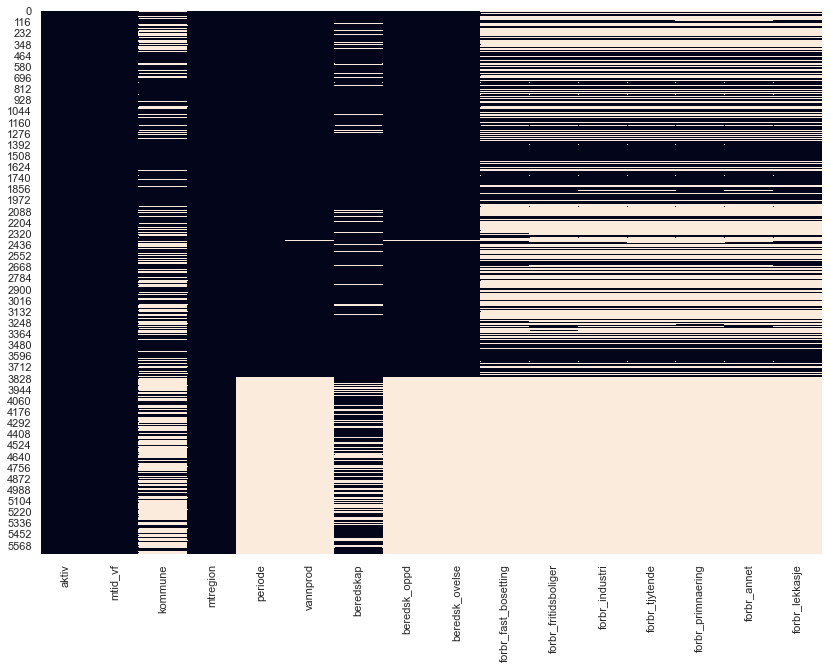

In [6]:
sns.set(rc={'figure.figsize':(14,10)})
sns.heatmap(fil.isna(), cbar=False)

In [7]:
print("Andelen av data som inneholder (nesten) fullstendige 7 kolonner er : {:.2f}".format(len(fil.loc[~(fil.periode.isna())])/len(fil)))

Andelen av data som inneholder (nesten) fullstendige 7 kolonner er : 0.67


## Rensing og preparering

Noen kolonner inneholder punkter (verken NAN eller tall)

In [8]:
fil.loc[fil['forbr_fritidsboliger']=='.']

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
3287,nei,Z1702091218358320371REJJC,NaN,Region Nord,2018.0,2800.0,ja,nei,nei,NaN,.,NaN,NaN,NaN,NaN,NaN
3291,ja,Z1702161138460852025TIGCY,NaN,Region Øst,2020.0,8447.0,ja,nei,nei,NaN,.,NaN,NaN,NaN,NaN,NaN
3294,nei,Z1703071232312352024CGYKZ,NaN,Region Øst,2017.0,200.0,ja,ja,nei,NaN,.,NaN,NaN,NaN,.,NaN
3310,ja,Z1705031420342933252WUZEB,NaN,Region Midt,2020.0,21213.0,ja,ja,ja,NaN,.,NaN,NaN,NaN,NaN,NaN
3326,ja,Z1707181104332842024EKCXO,Vestby,Region Stor-Oslo,2020.0,383.0,ja,ja,nei,NaN,.,NaN,NaN,NaN,NaN,NaN
3336,nei,Z1711081320185852025BNGRG,NaN,Region Øst,2018.0,2000.0,ja,ja,nei,NaN,.,NaN,NaN,NaN,NaN,NaN


In [9]:
fil.loc[fil['forbr_fast_bosetting']=='.']

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
3242,nei,Z1607201036252652024KGNIA,NaN,Region Nord,2018.0,147.0,ja,ja,ja,.,NaN,NaN,NaN,NaN,NaN,NaN


#### Fjerner alle rader som inneholder "." og gjør om fra objekt til tall
Det er ikke helt klart om "." skal erstattes med 0 eller NAN. Dermed, velger jeg å fjerne den.

In [10]:
forbruk_kol = fil.columns[-7:]
for k in forbruk_kol:
    fil = fil.loc[fil[k] != '.']
    fil[k] = fil[k].astype(np.float64)

Undersøker om det er noen "." i data settet:

In [11]:
fil.loc[fil['forbr_fritidsboliger'] == '.']

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje


In [12]:
fil.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5652 entries, 0 to 5663
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   aktiv                 5652 non-null   object 
 1   mtid_vf               5652 non-null   object 
 2   kommune               3230 non-null   object 
 3   mtregion              5652 non-null   object 
 4   periode               3808 non-null   float64
 5   vannprod              3801 non-null   float64
 6   beredskap             4856 non-null   object 
 7   beredsk_oppd          3800 non-null   object 
 8   beredsk_ovelse        3800 non-null   object 
 9   forbr_fast_bosetting  1939 non-null   float64
 10  forbr_fritidsboliger  1905 non-null   float64
 11  forbr_industri        1884 non-null   float64
 12  forbr_tjytende        1874 non-null   float64
 13  forbr_primnaering     1891 non-null   float64
 14  forbr_annet           1866 non-null   float64
 15  forbr_lekkasje       

In [13]:
fil.describe()

,periode,vannprod,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
count,3808.000000,3.801000e+03,1939.000000,1905.000000,1884.000000,1874.000000,1891.000000,1866.000000,1909.00000
mean,2017.610819,2.497107e+05,54.781336,5.628273,8.516395,5.258367,62.436531,3.487942,18.38264
std,3.413890,2.038935e+06,38.870697,9.757668,53.377981,8.655476,2301.256084,10.139390,16.81790
min,2008.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2016.000000,6.500000e+02,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.00000
50%,2020.000000,6.100000e+03,53.000000,2.000000,1.000000,3.000000,3.000000,0.000000,15.00000
75%,2020.000000,6.036300e+04,70.000000,6.000000,8.000000,7.000000,10.000000,4.000000,30.00000
max,2021.000000,9.490000e+07,1000.000000,100.000000,2021.000000,100.000000,100000.000000,100.000000,80.00000


Den første statiske beskrivelsen tar jeg med for å se på hele bildet før eventuell fjerning/manipulering av data. 

- Det som kan være verdt å bemerke seg, er at for vannpod, standard avviket er nærmest $10$ ganger større enn snittet, og at fordelingen ser ut til å være venstre forskjøvet. En antydnig til at det er behov for flere obervasjoner for denne variablen.

- Utfra beskrivelsen vet vi at noen av forbruksvariablene er hele tall mellom 0-100. 


### Undersøker ekstreme veridene i forburks kolonnene

In [14]:
fil.loc[fil.forbr_fast_bosetting > 100]

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
3241,nei,Z1607111221471292024GRUQL,NaN,Region Øst,2017.0,120.0,ja,nei,nei,1000.0,NaN,NaN,NaN,NaN,NaN,NaN
3870,nei,Z2002111012162822025SHZCW,NaN,Region Sør og Vest,NaN,NaN,ja,NaN,NaN,1000.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
fil.loc[fil.forbr_industri > 100]

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
3302,ja,Z1704041224134402024XLACH,NaN,Region Sør og Vest,2020.0,700.0,nei,nei,nei,NaN,NaN,2021.0,NaN,NaN,NaN,NaN
3715,ja,Z2102151506541182024FBIAM,NaN,Region Øst,2020.0,2317.0,ja,ja,ja,NaN,NaN,1000.0,NaN,NaN,NaN,NaN


In [16]:
fil.loc[fil.forbr_primnaering > 100]

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
21,ja,Z0704301335374051190QCWUR,Melhus,Region Midt,2020.0,25000.0,nei,ja,nei,50.0,5.0,0.0,5.0,4000.0,0.0,0.0
3798,ja,Z1803021402019832025MATAP,NaN,Region Øst,2020.0,1160.0,ja,ja,nei,NaN,NaN,NaN,NaN,100000.0,NaN,NaN


### Hvilke variabler/kolonner skal fjernes?

Dataen i vannforburkskolonnen har gjennomgående god kvalitet, og mer enn $\frac{2}{3}$ ikke-null verdier. For de resterende dataene er flere metoder for å håndtere NAN verdier (manglende verdier), blant annet:
1. Erstatte manglende verider med 0.
2. Erstatte de med snitt/median (i dette tilfelle er det viktig å ha nok data for å kunne si noe om den statistiske fordelingen)
3. Sammenligne med andre kolonner for å finne koorelasjonen, og dermed finne en linear funksjon $y = ax + b$
4. etc...

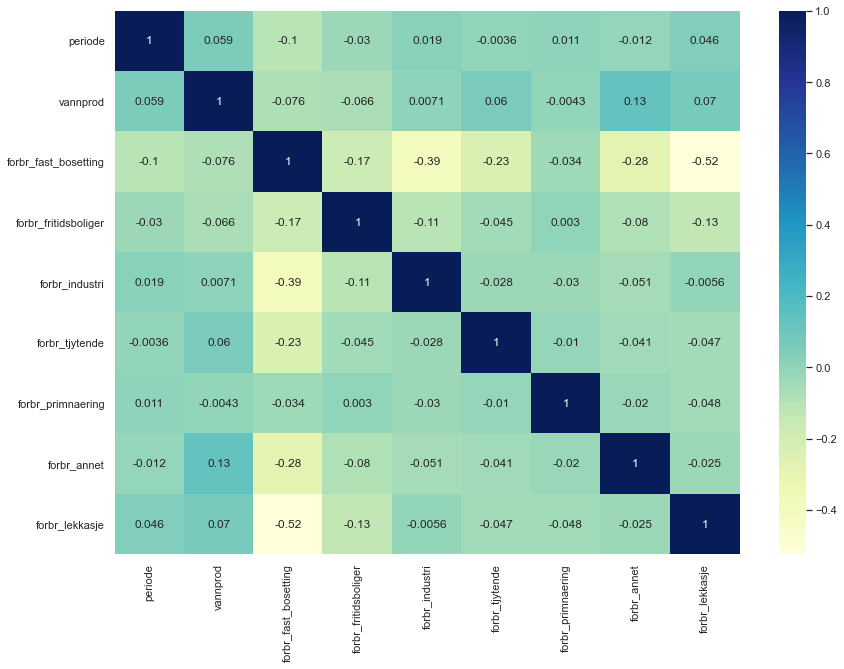

In [17]:
corr = fil.corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu")

Vi ser fra koorelasjonsmatrisen over at det er en korrelasjon mellom forbruk pga lekasje og forburk til fast bosetting.
Men fra bekrivenslen under ser vi at de to parameterene har få forskjellige observasjoner og dermed har vi lite å tjene på å lage en korrelasjon for å fylle manglende verdier

In [18]:
fil[['forbr_fast_bosetting', 'forbr_lekkasje']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5652 entries, 0 to 5663
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   forbr_fast_bosetting  1939 non-null   float64
 1   forbr_lekkasje        1909 non-null   float64
dtypes: float64(2)
memory usage: 132.5 KB


#### Undersøke alle aktive/ikke aktive vannverk


In [19]:
aktiv = fil.loc[fil.aktiv == 'ja']
ikke_aktiv = fil.loc[fil.aktiv=='nei']
aktiv_per_aar = aktiv.groupby('periode').count().reset_index()
ikke_aktiv_aar = ikke_aktiv.groupby('periode').count().reset_index()
print("Aktive vannverk:")
print(aktiv_per_aar[['periode', 'aktiv']])
print()
print("Ikke aktive vannverk")
print(ikke_aktiv_aar[['periode', 'aktiv']])
print(f'Antall aktive vannverk: {len(aktiv)}')
print(f'Antall ikke-aktive vannverk: {len(ikke_aktiv)}')
assert(len(fil) == len(aktiv)+len(ikke_aktiv))

Aktive vannverk:
    periode  aktiv
0    2009.0     11
1    2010.0     16
2    2011.0     16
3    2012.0     19
4    2013.0     19
5    2014.0     32
6    2015.0     31
7    2016.0     75
8    2017.0    101
9    2018.0     75
10   2019.0    120
11   2020.0   2015
12   2021.0      1

Ikke aktive vannverk
    periode  aktiv
0    2008.0     33
1    2009.0     87
2    2010.0    111
3    2011.0    102
4    2012.0    103
5    2013.0     95
6    2014.0    115
7    2015.0     68
8    2016.0    108
9    2017.0     84
10   2018.0    239
11   2019.0    107
12   2020.0     25
Antall aktive vannverk: 3134
Antall ikke-aktive vannverk: 2518


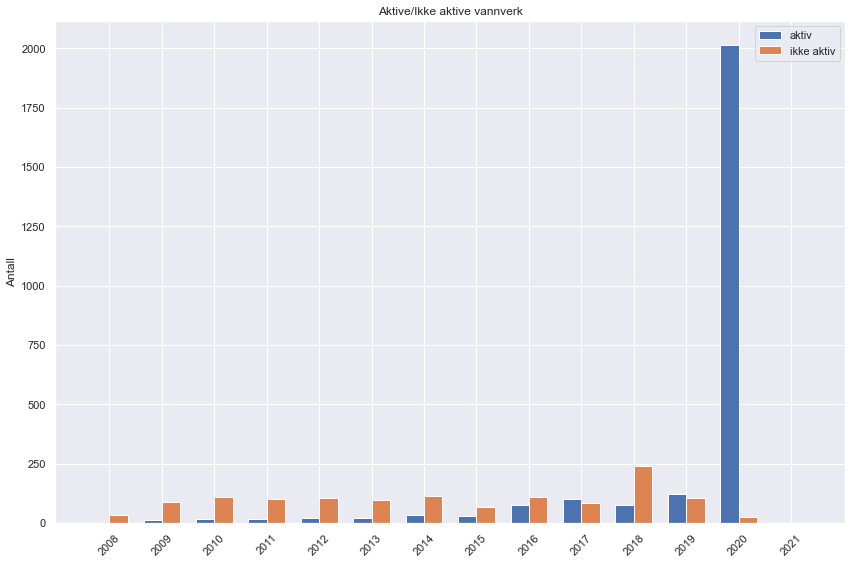

In [20]:
fig, ax = plt.subplots(figsize=(12,8))
width = 0.35
x = np.arange(len(aktiv_per_aar.periode)+1)
labels = [str(i)[0:4] for i in aktiv_per_aar.periode]
labels.insert(0, '2008')
y_1 =   np.insert(aktiv_per_aar.aktiv.values, 0, 0)

y_2 =  np.insert(ikke_aktiv_aar.aktiv.values, len(ikke_aktiv_aar.aktiv.values), 0)

rects1 = ax.bar(x - width/2, y_1 , width, label='aktiv')
rects2 = ax.bar(x + width/2, y_2 , width, label='ikke aktiv')

ax.set_ylabel('Antall')
ax.set_title('Aktive/Ikke aktive vannverk')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

# ax.bar_label(rects1, padding=3)
# ax.bar_label(rects2, padding=3)

fig.tight_layout()

plt.show()

Det er mange flere observasjoner fra aktive 2020 vannverk sammenlignet med andre år. 
- Har det skjedd en endring som har forårsaket dette i 2020?
- Eller, er det rimlig å anta at stikkprøvene er sentrert rundt år 2020 og spesielt rundt de aktive vannverk. 
- En annen hypotese kan være at utrekket/datatilgjenglighet er årsaken. Det kan også være en kombinasjon.

En naturlig progresjon i dette tidspunktet er å fjerne alle data som innholder NAN i den  nederste $\frac{1}{3}$ delen av datasettet.
Men før vi gjør det kan det være interessant å se på om dataen vi sitter igjen med er representativt for resterende data.
For utføre en slik sammenligning:
- Vi ser på fordeling av utført beredskap før og etter fjerning av manglende data. 

In [21]:
for_sletting = fil[['aktiv','beredskap']]

In [22]:
for_sletting.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5652 entries, 0 to 5663
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   aktiv      5652 non-null   object
 1   beredskap  4856 non-null   object
dtypes: object(2)
memory usage: 132.5+ KB


In [23]:
for_sletting = for_sletting.dropna()
for_sletting.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4856 entries, 0 to 5663
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   aktiv      4856 non-null   object
 1   beredskap  4856 non-null   object
dtypes: object(2)
memory usage: 113.8+ KB


##### Antall aktive/ikke-aktive før sletting av NAN verider

In [24]:
for_sletting['beredskap'].value_counts()

ja     3726
nei    1130
Name: beredskap, dtype: int64

<BarContainer object of 2 artists>

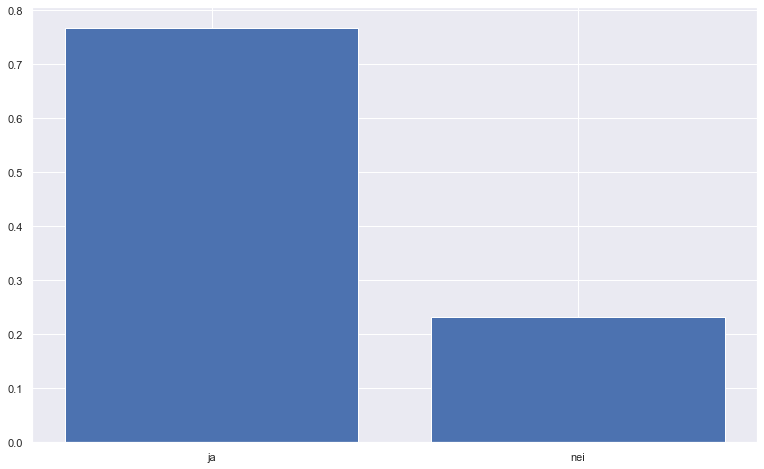

In [25]:
plt.figure(figsize=(13,8))
plt.bar(['ja', 'nei'], for_sletting['beredskap'].value_counts()/len(for_sletting))

Etter sletting av NAN verdier

In [26]:
# Fjerner den nedeste 1/3 med NAN verdier
fil = fil.loc[~(fil['periode'].isna())]

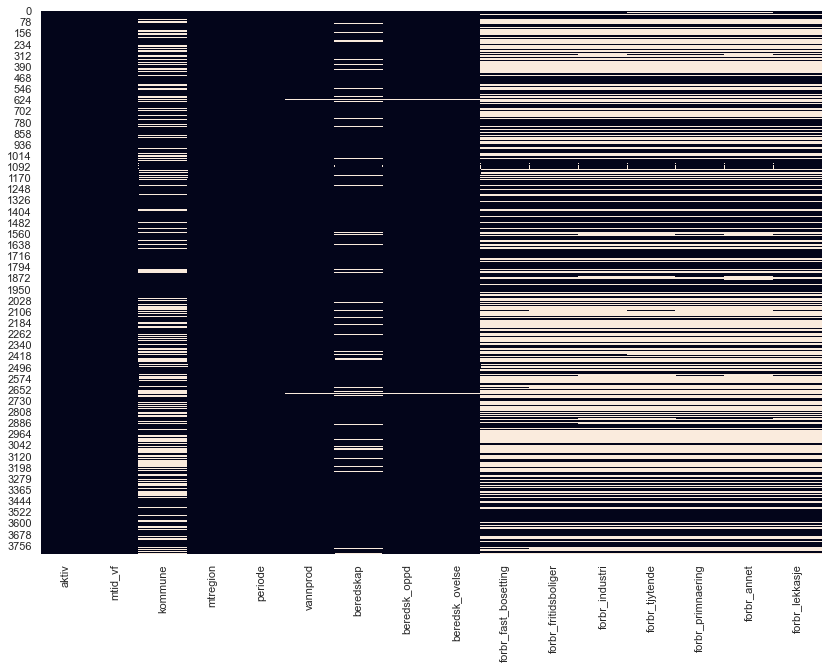

In [27]:
sns.set(rc={'figure.figsize':(14,10)})
sns.heatmap(fil.isna(), cbar=False)

<ipython-input-28-a98f2b463728>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  etter_sletting.dropna(inplace=True)


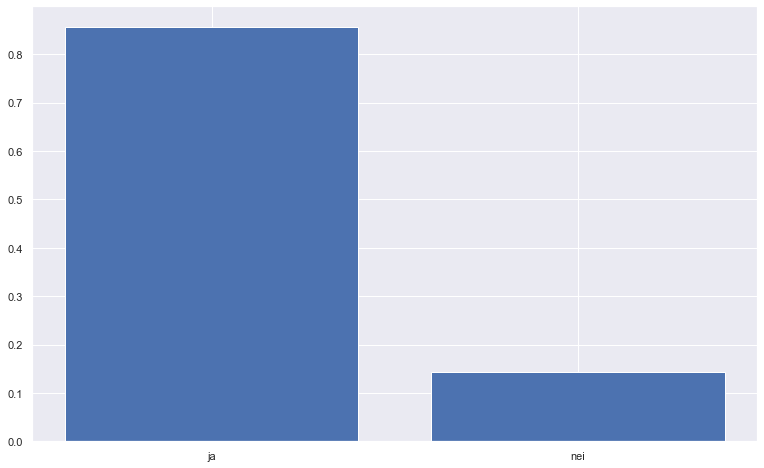

In [28]:
etter_sletting =  fil[['aktiv','beredskap']]
etter_sletting.dropna(inplace=True)
plt.figure(figsize=(13,8))
plt.bar(['ja', 'nei'], etter_sletting['beredskap'].value_counts()/len(etter_sletting));

Det er flere ikke-aktive data som ble fjernet. Det kan ha en konsekvens når man skal undersøke hvorfor noen vannverk blir ikke-aktive. Men, til dette formålet, er det forsvarlig å slette de verdiene, da det er "liten" endring i forholdet, og jeg er ikke kjent med prosessene som har produsert dette datasettet.

##### Fjerner verdier som er over $100$%

In [29]:
# Fjerne verdier som er over 100%
fil = fil.loc[fil.forbr_primnaering <= 100]
fil = fil.loc[fil.forbr_industri <= 100]
fil = fil.loc[fil.forbr_primnaering <= 100]
print(f"Antall rader i filen etter å ha fjernet dårlig manglende data blir da: {len(fil)}")


Antall rader i filen etter å ha fjernet dårlig manglende data blir da: 1868


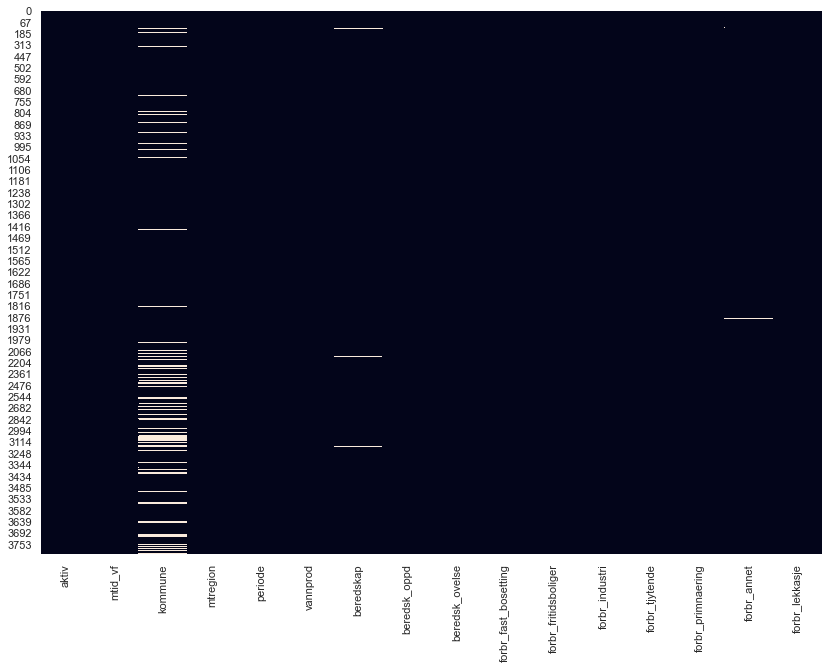

In [30]:
sns.set(rc={'figure.figsize':(14,10)})
sns.heatmap(fil.isna(), cbar=False)

#### Ser på ingen produksjon sammenlignet med vannforbruk 

In [31]:
ingen_produksjon = fil.loc[fil.vannprod <= 0]

In [32]:
ingen_produksjon.head(20)

,aktiv,mtid_vf,kommune,mtregion,periode,vannprod,beredskap,beredsk_oppd,beredsk_ovelse,forbr_fast_bosetting,forbr_fritidsboliger,forbr_industri,forbr_tjytende,forbr_primnaering,forbr_annet,forbr_lekkasje
4,ja,Z0704301334355061189GZVWT,Ålesund,Region Midt,2020.0,0.0,ja,ja,ja,6.0,3.0,74.0,1.0,5.0,2.0,9.0
5,ja,Z0704301334357881189ULHXL,Ålesund,Region Midt,2020.0,0.0,ja,nei,nei,82.0,6.0,0.0,0.0,5.0,2.0,5.0
22,ja,Z0704301335381471190MBXUL,Melhus,Region Midt,2020.0,0.0,nei,ja,nei,35.0,0.0,11.0,0.0,0.0,20.0,34.0
41,ja,Z0704301335460001189ALSLP,Indre Fosen,Region Midt,2020.0,0.0,ja,ja,ja,70.0,3.0,0.0,0.0,0.0,27.0,0.0
60,nei,Z0704301335539761189TSLTA,Rennebu,Region Midt,2018.0,0.0,nei,nei,nei,55.0,10.0,0.0,0.0,17.0,10.0,8.0
70,ja,Z0704301336003361189BBNSX,Vestre Toten,Region Øst,2019.0,0.0,ja,ja,ja,37.0,0.0,3.0,5.0,5.0,0.0,50.0
150,ja,Z0704301337285671190FAXCS,Hitra,Region Midt,2020.0,0.0,nei,nei,nei,80.0,0.0,0.0,20.0,0.0,0.0,0.0
287,nei,Z0704301339336871190YHSDK,Stryn,Region Sør og Vest,2015.0,0.0,nei,nei,nei,50.0,5.0,5.0,0.0,10.0,0.0,30.0
419,nei,Z0704301340599851189SNUVJ,Alver,Region Sør og Vest,2009.0,0.0,nei,nei,nei,88.0,1.0,0.0,0.0,10.0,0.0,1.0
483,ja,Z0704301341448681189RXOHR,Lillestrøm,Region Stor-Oslo,2019.0,0.0,ja,nei,nei,51.0,0.0,0.0,0.0,49.0,0.0,0.0


Vi ser at selv om vannproduksjon er 0, har noen vannverk hatt et forbruk foskjellig fra 0:
1. Kan dette skyldes at vannforbruksprosenten er predefinert og ikke det som er faktisk prosentfordeling?
2. Referer vannproduksjonskolonnen til deler av året?
3. Feil i data?

## Visualisering

#### Vi ser på sammenhengen mellom vannproduksjon og tilsvarende vannforbruk

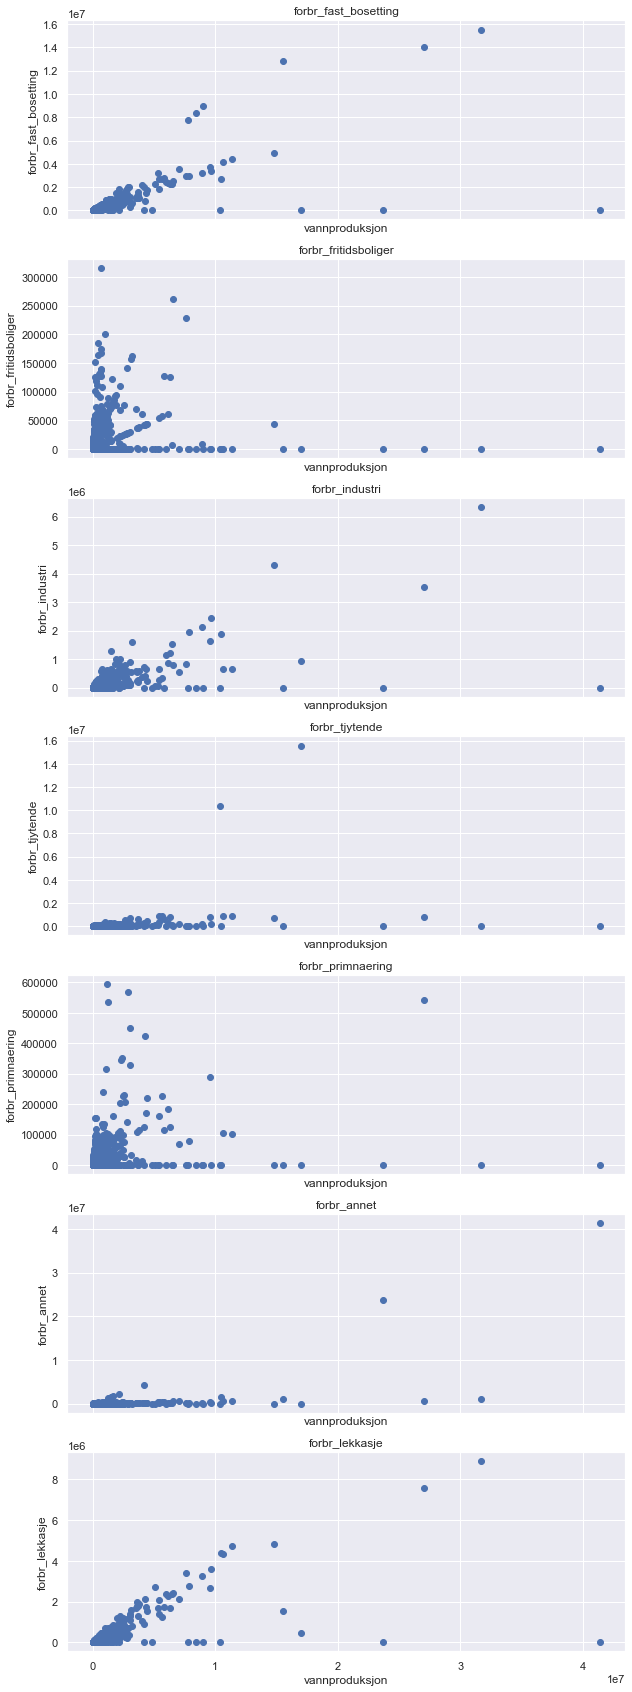

In [33]:
fil.columns
fig, ax = plt.subplots(nrows=7, ncols=1, sharex=True,figsize=(10, 30))
kolonner = fil.columns[-7:]
test_df = fil.loc[fil.vannprod != fil.vannprod.max()]
for i, k in enumerate(kolonner):
    f = test_df[['vannprod', k]].dropna()
    f['faktisk_prod'] = f['vannprod'] * (f[k]/100.0)
    f = f.loc[f[k] != '.']
    ax[i].scatter(f.vannprod, f['faktisk_prod'])
    ax[i].set_xlabel('vannproduksjon')
    ax[i].set_ylabel(k)
    ax[i].set_title(k)

# Statistikk 

### Koorelasjon og regresjonsanalyse.

In [34]:
import statsmodels.api as sm

In [35]:
osl_df = fil[['vannprod', 'forbr_lekkasje']].dropna()
osl_df['faktisk_prod'] = osl_df['vannprod'] * (osl_df['forbr_lekkasje']/100.0)

Text(0, 0.5, 'forbruk lekasje')

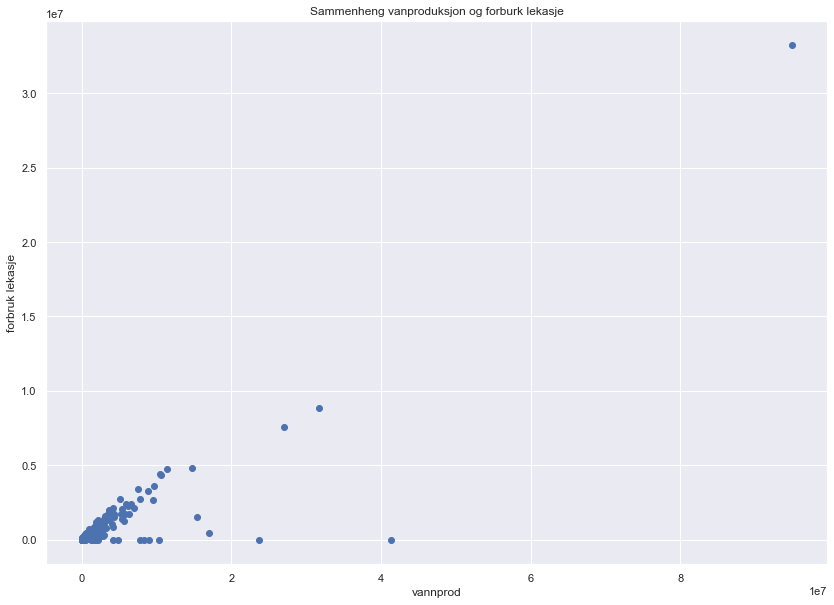

In [36]:
plt.scatter(osl_df['vannprod'], osl_df['faktisk_prod'])
plt.title('Sammenheng vanproduksjon og forburk lekasje')
plt.xlabel('vannprod')
plt.ylabel('forbruk lekasje')

In [37]:
osl_df.loc[osl_df.vannprod == osl_df.vannprod.max()]

,vannprod,forbr_lekkasje,faktisk_prod
1464,94900000.0,35.0,33215000.0


In [38]:

osl_model = sm.OLS(osl_df['faktisk_prod'], osl_df['vannprod'])
resultat = osl_model.fit()
resultat.params

vannprod    0.274045
dtype: float64

In [39]:
print(resultat.summary())

                                 OLS Regression Results                                
Dep. Variable:           faktisk_prod   R-squared (uncentered):                   0.797
Model:                            OLS   Adj. R-squared (uncentered):              0.797
Method:                 Least Squares   F-statistic:                              7319.
Date:                Wed, 15 Dec 2021   Prob (F-statistic):                        0.00
Time:                        09:04:07   Log-Likelihood:                         -26752.
No. Observations:                1867   AIC:                                  5.351e+04
Df Residuals:                    1866   BIC:                                  5.351e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Text(0, 0.5, 'forbruk lekasje')

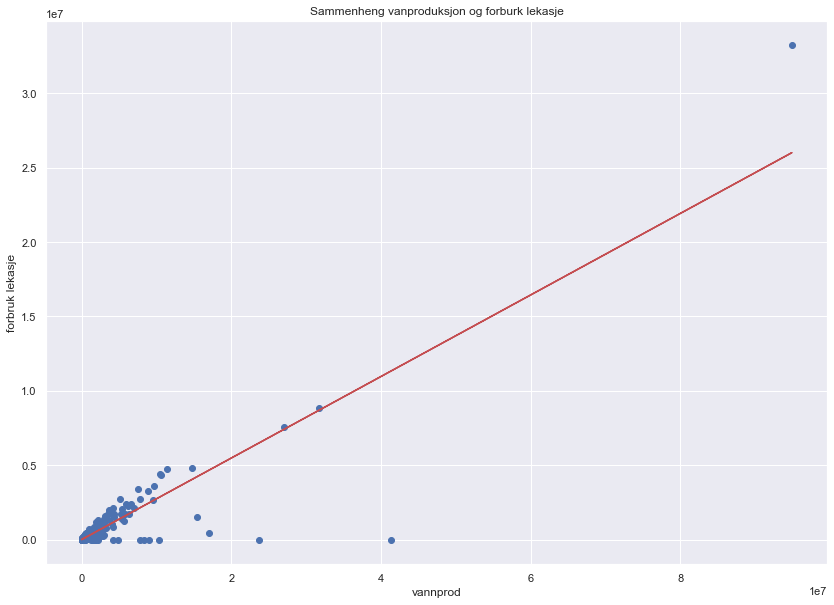

In [42]:
plt.scatter(osl_df['vannprod'], osl_df['faktisk_prod'])
plt.plot(osl_df['vannprod'], osl_df['vannprod']*0.2740, color='r')
plt.title('Sammenheng vanproduksjon og forburk lekasje')
plt.xlabel('vannprod')
plt.ylabel('forbruk lekasje')